In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 370.9 kB/s  0:00:059.7 kB/s eta 0:00:01:02


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [4]:
# Load dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [9]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 13, Samples: 178


In [12]:
# 1. Baseline: Single Decision Tree
dtree = DecisionTreeClassifier(random_state=42)

# 2. Bagging: Uses multiple trees in parallel (Bootstrap Aggregating)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), 
                            n_estimators=50, 
                            random_state=42)

# 3. AdaBoost: Sequential boosting, weights misclassified points higher
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), 
                              n_estimators=50, 
                              learning_rate=1.0, 
                              random_state=42)

# 4. XGBoost: Optimized Gradient Boosting
xgboost = XGBClassifier(n_estimators=50, 
                        learning_rate=0.1, 
                        max_depth=3, 
                        use_label_encoder=False, 
                        eval_metric='mlogloss',
                        random_state=42)

# Dictionary for iteration
models = {
    "Decision Tree": dtree,
    "Bagging (DT)": bagging,
    "AdaBoost": adaboost,
    "XGBoost": xgboost
}

Decision Tree Accuracy: 0.9444
Bagging (DT) Accuracy: 0.9722
AdaBoost Accuracy: 0.9444
XGBoost Accuracy: 0.9722


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [11:40:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/var/folders/f8/5b1yzp6s0xjcjnjjs6h5ztn80000gn/T/ipykernel_37076/3349927603.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


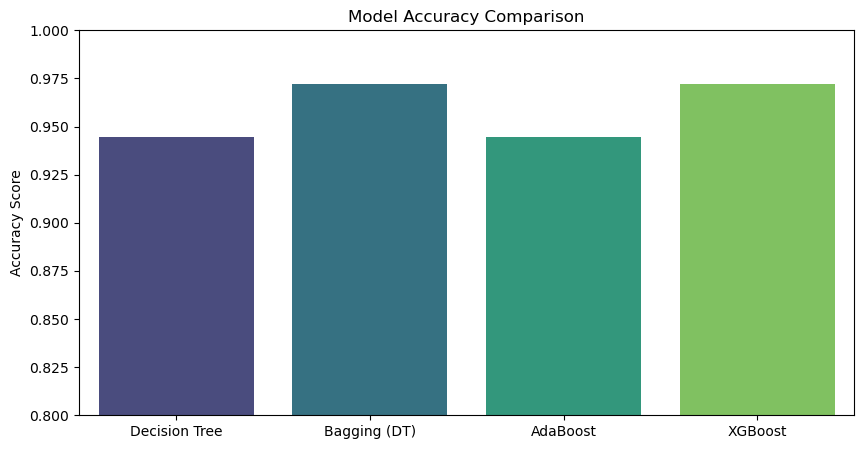

In [13]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Visualize Performance Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.ylim(0.8, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()